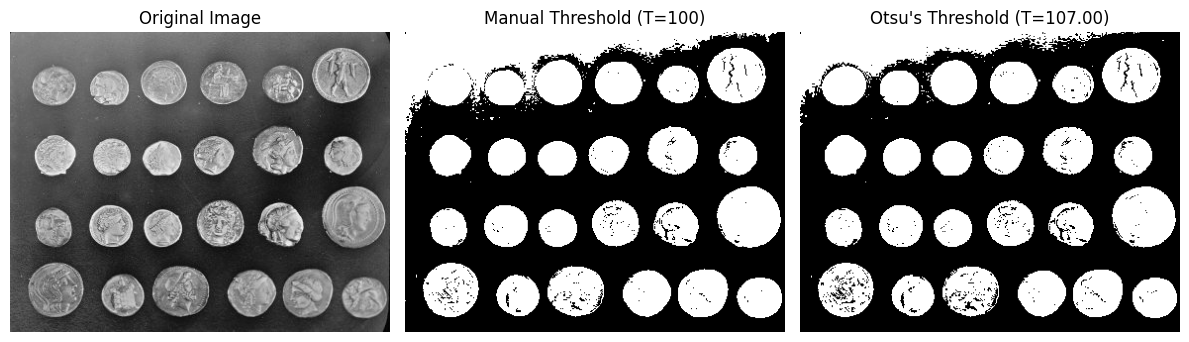

Nilai threshold Otsu yang ditemukan: 107


In [5]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Memuat citra (contoh: coins)
image_coins = data.coins() # Citra sudah grayscale

# 2. Thresholding Global (manual)
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

### Kesimpulan Praktikum: Thresholding

Berdasarkan percobaan menggunakan citra `coins`, dapat disimpulkan bahwa:

1.  **Thresholding Manual**: Hasil segmentasi sangat bergantung pada nilai ambang ($T$) yang ditentukan oleh pengguna. Jika nilai $T$ tidak tepat (terlalu rendah atau terlalu tinggi), objek koin tidak akan terpisah dengan sempurna dari latar belakang (terjadi *under-segmentation* atau *over-segmentation*).
2.  **Thresholding Otsu**: Metode ini jauh lebih efektif karena algoritma mencari nilai ambang optimal secara otomatis dengan meminimalkan varians dalam-kelas (*intra-class variance*). Dari hasil eksekusi, nilai Otsu sekitar **107.00** memberikan hasil pemisahan objek yang jauh lebih bersih dan akurat dibandingkan nilai manual **100**.
3.  **Aplikasi**: Metode thresholding sangat cocok digunakan pada citra yang memiliki kontras tinggi antara objek dan latar belakang (histrogram bimodal), seperti pada kasus koin ini.

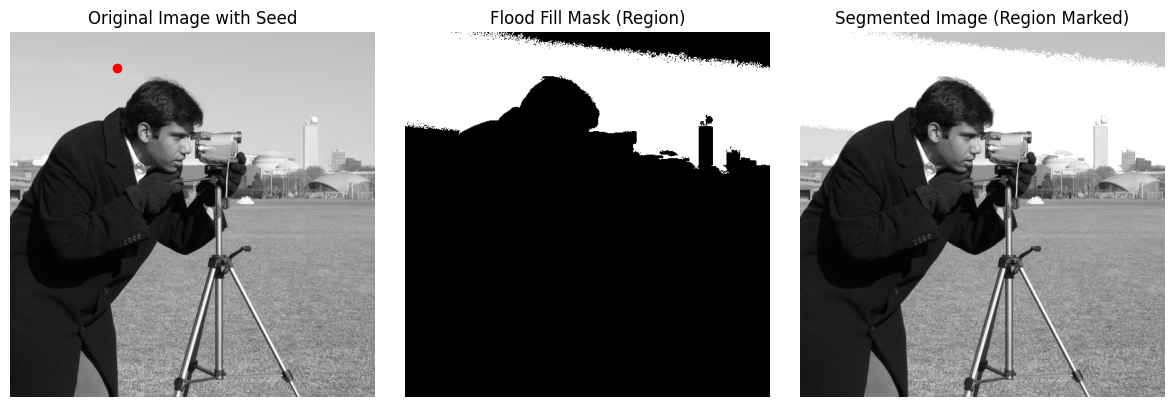

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Kesimpulan Praktikum: Region-Based Segmentation (Flood Fill)

Berdasarkan percobaan pada blok kode kedua menggunakan citra `camera`, dapat disimpulkan bahwa:

1.  **Mekanisme Flood Fill**: Algoritma ini bekerja dengan cara 'mengisi' area yang terhubung mulai dari titik benih (*seed point*) yang ditentukan. Dalam kasus ini, titik `(50, 150)` berada pada area langit.
2.  **Peran Parameter Tolerance**: Parameter `tolerance=10` menentukan ambang batas perbedaan intensitas warna antara piksel tetangga dengan piksel referensi agar dapat dianggap sebagai satu region. Semakin besar nilai toleransi, semakin luas area yang akan tersegmentasi.
3.  **Kelebihan**: Sangat efektif untuk mengisolasi objek atau area tertentu yang memiliki intensitas warna yang seragam dan saling terhubung secara spasial.
4.  **Keterbatasan**: Sangat sensitif terhadap pemilihan lokasi *seed point*. Jika *seed point* diletakkan pada area yang salah, atau jika toleransi terlalu tinggi, segmentasi dapat 'bocor' ke area yang tidak diinginkan.

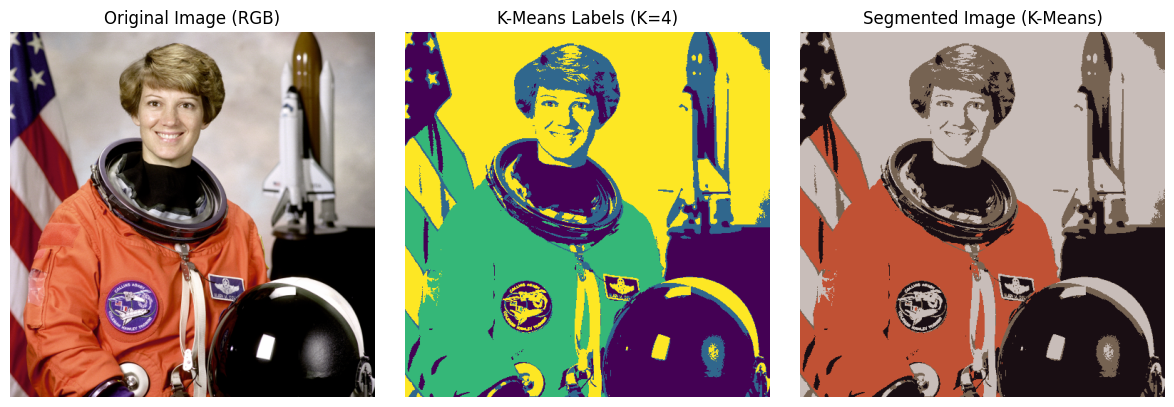

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna
image_astro = data.astronaut()
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape dan konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra tersegmentasi
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    mask_k = (segmented_labels == k)
    segmented_image_kmeans[mask_k] = centers_lab[k]

segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Kesimpulan Praktikum: Clustering-Based Segmentation (K-Means)

Berdasarkan percobaan pada blok kode ketiga menggunakan citra `astronaut`, dapat disimpulkan bahwa:

1.  **Segmentasi Berbasis Warna**: K-Means mengelompokkan piksel berdasarkan kemiripan nilai warna dalam ruang warna Lab. Penggunaan ruang warna Lab (bukan RGB biasa) membantu algoritma mengenali perbedaan warna yang lebih sesuai dengan persepsi manusia.
2.  **Pengaruh Nilai K**: Parameter `n_clusters=4` menentukan jumlah warna dominan yang akan dihasilkan pada citra tersegmentasi. Semakin besar nilai K, semakin detail variasi warna yang dipertahankan, namun semakin kompleks pembagian wilayahnya.
3.  **Kelebihan**: Sangat efektif untuk penyederhanaan warna (*color quantization*) dan mengisolasi objek berdasarkan karakteristik spektral (warna/intensitas) tanpa mempedulikan posisi spasial piksel.
4.  **Kekurangan**: Algoritma ini tidak mempertimbangkan apakah piksel-piksel tersebut saling bertetangga atau tidak, sehingga terkadang menghasilkan 'noise' atau bintik-bintik kecil pada area yang seharusnya seragam.

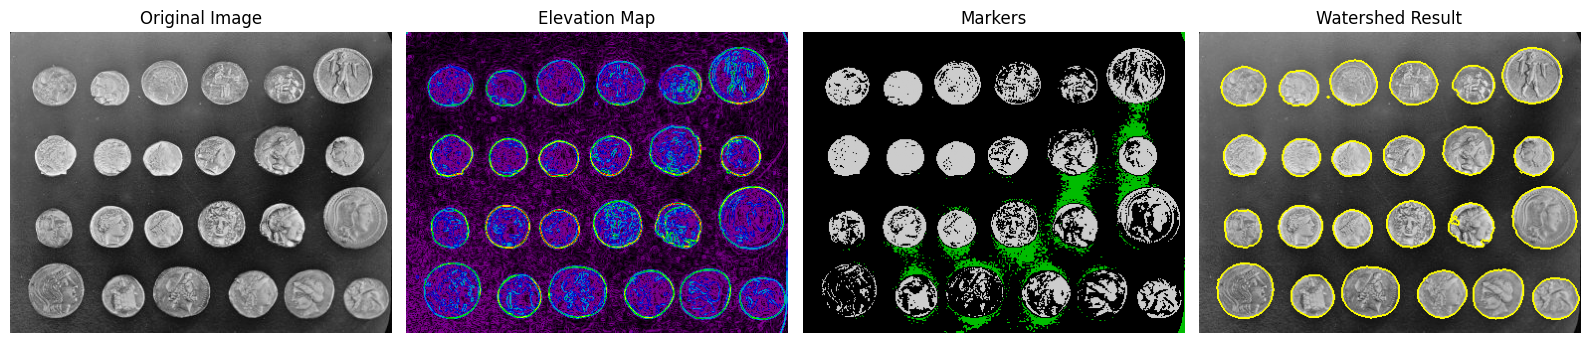

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation

# 1. Memuat citra
image_coins = data.coins()

# 2. Hitung gradien
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker sederhana
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

# 4. Terapkan Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Result')
ax[3].axis('off')

plt.tight_layout()
plt.show()

### Kesimpulan Praktikum: Morphological-Based Segmentation (Watershed)

Berdasarkan percobaan pada blok kode keempat menggunakan citra `coins`, dapat disimpulkan bahwa:

1.  **Analogi Topografi**: Algoritma Watershed bekerja dengan menganggap gradien citra (*elevation map*) sebagai permukaan topografi. Air 'mengalir' dari penanda (*markers*) dan mengisi cekungan hingga bertemu di garis pembatas (watershed lines).
2.  **Pentingnya Marker**: Kunci keberhasilan segmentasi ini terletak pada penentuan *markers*. Dalam kode ini, kita menetapkan intensitas rendah sebagai latar belakang (marker 1) dan intensitas tinggi sebagai koin (marker 2). Tanpa marker yang tepat, algoritma ini rentan terhadap *over-segmentation* (pecahnya satu objek menjadi banyak bagian kecil).
3.  **Kelebihan**: Sangat efektif untuk memisahkan objek-objek yang saling bersentuhan atau berhimpitan, yang sulit dilakukan hanya dengan thresholding biasa.
4.  **Elevation Map**: Penggunaan filter Sobel sangat krusial di sini untuk menonjolkan batas tepi objek sebagai 'dinding' pemisah antar cekungan air.

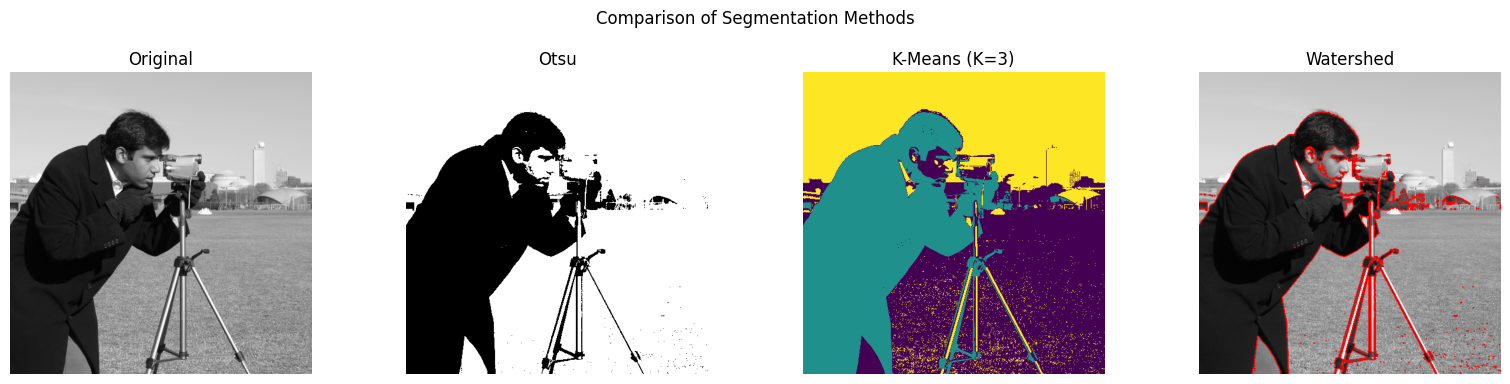

In [9]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Load data
image = data.camera()
image_float = img_as_float(image)

# 2. Otsu
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# 3. K-Means
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# 4. Watershed
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 5. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

sw_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1,0,0))
ax[3].imshow(sw_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Kesimpulan Praktikum: Perbandingan Metode Segmentasi

Berdasarkan perbandingan antara metode Otsu, K-Means, dan Watershed pada citra yang sama (`camera`), dapat ditarik kesimpulan umum:

1.  **Otsu Thresholding**: Paling sederhana dan cepat. Sangat efektif jika kita hanya perlu memisahkan citra menjadi dua bagian (biner) berdasarkan intensitas, namun kurang detail jika citra memiliki banyak variasi objek.
2.  **K-Means Clustering**: Mampu mengelompokkan citra ke dalam beberapa tingkat (K > 2) berdasarkan nilai piksel. Sangat berguna untuk kuantisasi warna atau menyederhanakan kompleksitas citra menjadi beberapa wilayah dominan.
3.  **Watershed Segmentation**: Memberikan hasil yang paling presisi dalam menentukan batas-batas objek (*boundaries*), terutama jika dibantu dengan peta gradien (Sobel) dan penentuan marker yang tepat. Metode ini paling unggul dalam menjaga integritas bentuk objek dibandingkan thresholding biasa.
4.  **Pemilihan Metode**: Pemilihan algoritma sangat bergantung pada karakteristik citra input dan tujuan akhir segmentasi. Tidak ada satu metode yang selalu terbaik untuk semua jenis citra.

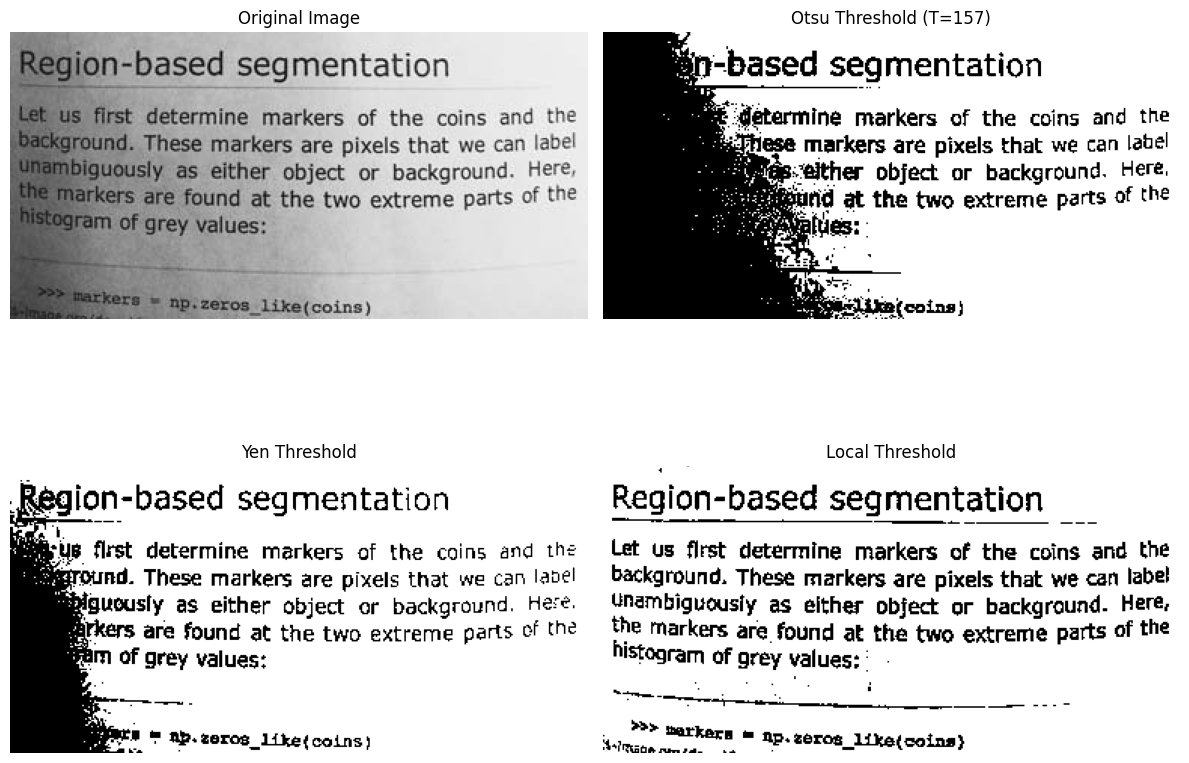

In [10]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

# 1. Memuat citra page
image_page = data.page()

# 2. Menerapkan Otsu
thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# 3. Menerapkan Yen
thresh_yen = filters.threshold_yen(image_page)
binary_yen = image_page > thresh_yen

# 4. Menerapkan Local Thresholding (Sangat baik untuk dokumen)
# block_size harus ganjil
block_size = 35
binary_local = filters.threshold_local(image_page, block_size, offset=10)
binary_local_res = image_page > binary_local

# 5. Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax = axes.ravel()

ax[0].imshow(image_page, cmap='gray')
ax[0].set_title('Original Image')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu Threshold (T={thresh_otsu})')

ax[2].imshow(binary_yen, cmap='gray')
ax[2].set_title('Yen Threshold')

ax[3].imshow(binary_local_res, cmap='gray')
ax[3].set_title('Local Threshold')

for a in ax: a.axis('off')
plt.tight_layout()
plt.show()

### Analisis Eksperimen Thresholding pada `data.page()`

1. **Apakah hasil Otsu memuaskan?**
   - **Tidak.** Hasil Otsu biasanya gagal pada citra ini karena adanya pencahayaan yang tidak merata (gradien gelap-terang). Otsu adalah *global thresholding* yang mencari satu nilai ambang untuk seluruh citra, sehingga area yang lebih gelap di bagian bawah/samping teks seringkali ikut terhapus atau dianggap sebagai latar belakang gelap.

2. **Perbandingan dengan Metode Lain:**
   - **Yen Thresholding**: Mirip dengan Otsu, ini adalah metode global. Meskipun terkadang lebih baik dari Otsu dalam kasus tertentu, ia tetap kesulitan menangani bayangan/pencahayaan yang tidak merata pada dokumen.
   - **Local Thresholding (Adaptive)**: Memberikan hasil **paling memuaskan**. Metode ini menghitung ambang batas untuk setiap piksel berdasarkan area tetangganya (*local neighborhood*). Hal ini memungkinkan algoritma untuk mengompensasi perubahan pencahayaan di berbagai bagian kertas, sehingga teks tetap terbaca jelas di seluruh halaman.

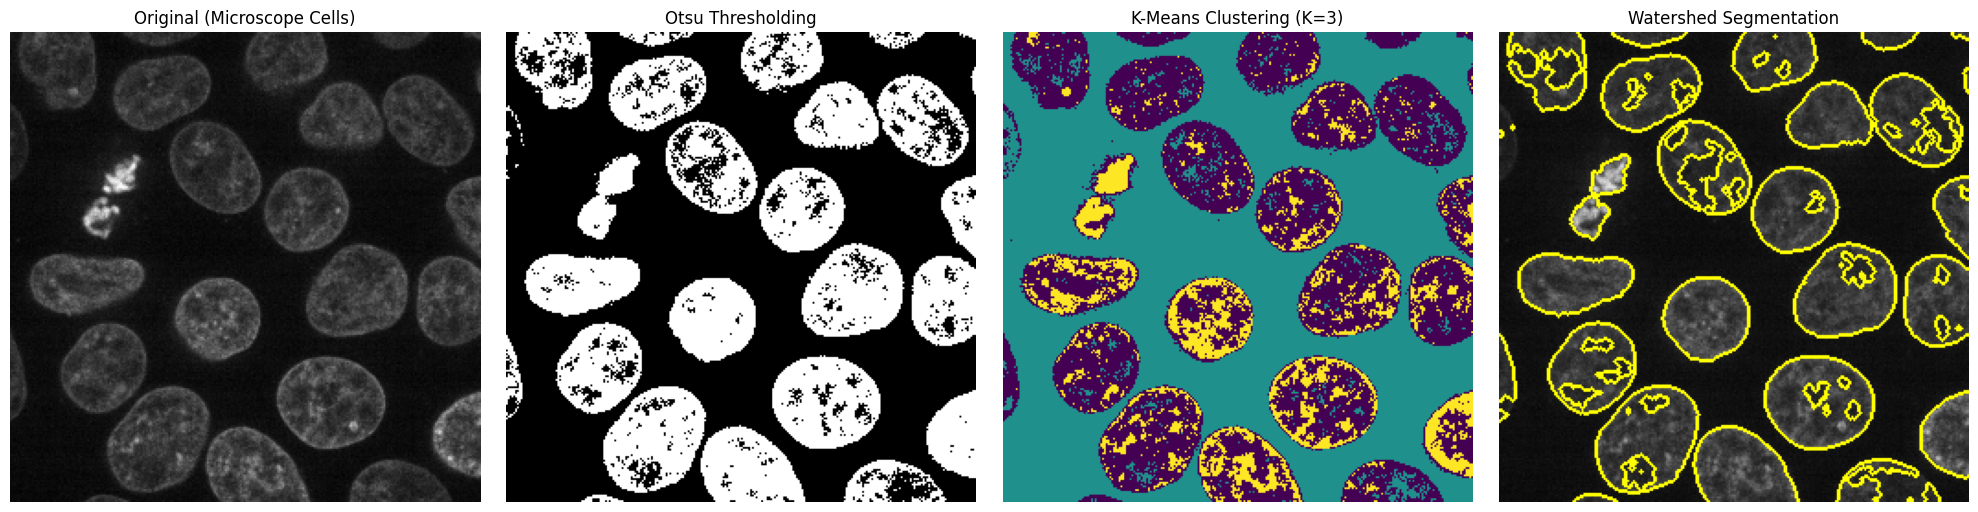

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, color, img_as_float
from sklearn.cluster import KMeans
import warnings

# 1. Memuat citra contoh (Citra sel mikroskop dari skimage)
image = data.cells3d()[30, 1, :, :] # Mengambil satu slice citra sel
image_float = img_as_float(image)

# 2. Metode 1: Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# 3. Metode 2: K-Means Clustering (K=3: Latar, Sitoplasma, Inti)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    labels = kmeans.fit_predict(pixel_features)
segmented_kmeans = labels.reshape(rows, cols)

# 4. Metode 3: Watershed
# Menggunakan sobel untuk elevation map dan otsu untuk markers
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu * 0.7] = 1 # Latar belakang
markers[image > thresh_otsu * 1.3] = 2 # Objek sel
segmentation_watershed = segmentation.watershed(elevation_map, markers)
boundaries = segmentation.mark_boundaries(image_float, segmentation_watershed)

# 5. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original (Microscope Cells)')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu Thresholding')

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title('K-Means Clustering (K=3)')

ax[3].imshow(boundaries)
ax[3].set_title('Watershed Segmentation')

for a in ax: a.axis('off')
plt.tight_layout()
plt.show()

### Diskusi Hasil Segmentasi Citra Sel Mikroskop

**Analisis Perbandingan:**
1.  **Otsu Thresholding**: Menghasilkan segmentasi biner yang bersih jika kontras sel dan latar belakang sangat kuat. Namun, Otsu cenderung mengabaikan variasi intensitas di dalam sel (seperti inti vs sitoplasma).
2.  **K-Means Clustering**: Paling cocok untuk citra ini karena mampu membedakan tingkat intensitas yang berbeda (misalnya memisahkan latar belakang yang sangat gelap, sitoplasma yang redup, dan inti sel yang terang) berkat penggunaan $K > 2$.
3.  **Watershed**: Sangat baik dalam mendefinisikan batas tepi sel yang akurat, namun sangat bergantung pada penentuan *markers* yang tepat. Jika markers tidak presisi, bisa terjadi *leakage* (kebocoran) antar sel.

**Kesimpulan:**
Untuk citra sel mikroskop ini, **K-Means** atau **Watershed** adalah yang paling cocok. K-Means unggul dalam membedakan organel berdasarkan intensitas, sementara Watershed unggul jika tujuannya adalah memisahkan sel-sel yang saling berhimpitan secara spasial.